# Übung 1: Grundlagen iterativer Verfahren
**Kurs:** Iterative Lösung großer Gleichungssysteme  
**Semester:** Sommersemester 2026  
**Datum:** 23.04.2026  
**Institut:** Institute for Analysis and Scientific Computing, TU Wien  
---
### Hosan Youssef: 1648939
---

## Model Problem: 1D-Poisson Equation

We consider the domain $\Omega=(0,1)$ and the **1D-Poisson problem** with homogeneous Dirichlet boundary conditions:

$$
\begin{aligned}
-u'' &= 1 \quad \text{in } \Omega, \\
u(0) = u(1) &= 0.
\end{aligned} \tag{1}
$$

### Discretization via Finite Differences

Let $n \in \mathbb{N}$, $h = 1/(n+1)$, and the grid points $x_j = jh$ for $j=0, \dots, n+1$. We approximate the exact solution $u_j \approx u(x_j)$ via finite differences:

$$
-\frac{u_{j-1} - 2u_j + u_{j+1}}{h^2} = 1 \quad \text{for } j=1, \dots, n,
$$

with $u_0 = u_{n+1} = 0$. This leads to the linear system $\mathbf{A}\mathbf{u} = \mathbf{b}$ with:

$$
\mathbf{A} = \frac{1}{h^2} \begin{pmatrix} 
2 & -1 & & & \\
-1 & 2 & -1 & & \\
& -1 & 2 & \ddots & \\
& & \ddots & \ddots & -1 \\
& & & -1 & 2 
\end{pmatrix} \in \mathbb{R}^{n \times n}
\quad \text{and} \quad
\mathbf{b} = \begin{pmatrix} 1 \\ \vdots \\ 1 \end{pmatrix} \in \mathbb{R}^n. \tag{2}
$$





# Existence and Uniqueness: The Lax-Milgram Theorem

 To prove the existence of a unique solution for the Poisson problem (1), we consider its **weak formulation**. 

## 1. Weak Formulation
 We multiply the equation $-u'' = 1$ by a test function $v \in H_0^1(0,1)$ and integrate over the domain $\Omega = (0,1)$:

$$-\int_0^1 u''(x)v(x) \, dx = \int_0^1 1 \cdot v(x) \, dx$$

Using integration by parts and the boundary conditions $v(0)=v(1)=0$, we obtain the variational formulation: 
Find $u \in H_0^1(\Omega)$ such that
$$a(u,v) = F(v) \quad \forall v \in H_0^1(\Omega)$$

where:
* **Bilinear form:** $a(u,v) = \int_0^1 u'(x)v'(x) \, dx$
* **Linear functional:** $F(v) = \int_0^1 v(x) \, dx$

## 2. Requirements of Lax-Milgram
The Lax-Milgram Theorem guarantees a unique solution if the following conditions are met:

### a) Continuity of the Bilinear Form
By the Cauchy-Schwarz inequality:
$$|a(u,v)| = \left| \int_0^1 u'v' \, dx \right| \le \|u'\|_{L^2} \|v'\|_{L^2} = |u|_{H^1} |v|_{H^1} \le \|u\|_{H^1} \|v\|_{H^1}$$
Thus, $a(\cdot, \cdot)$ is continuous with constant $M=1$.

### b) Coercivity of the Bilinear Form
Since we are in the space $H_0^1(0,1)$ with zero boundary conditions, the **Poincaré inequality** applies: there exists $C_P > 0$ such that $\|v\|_{L^2} \le C_P |v|_{H^1}$.  It follows that:
$$a(v,v) = \int_0^1 (v')^2 \, dx = |v|_{H^1}^2 \ge \alpha \|v\|_{H^1}^2$$
The bilinear form is therefore coercive.

### c) Continuity of the Linear Functional
Since the right-hand side $f=1$ is in $L^2(0,1)$, we have:
$$|F(v)| = \left| \int_0^1 1 \cdot v \, dx \right| \le \|1\|_{L^2} \|v\|_{L^2} \le 1 \cdot \|v\|_{H^1}$$
Thus, $F(\cdot)$ is a bounded (continuous) linear functional.

## Conclusion
As all requirements are satisfied, the **Lax-Milgram Theorem** ensures the existence and uniqueness of a weak solution $u \in H_0^1(\Omega)$.

## Exercise 1 (Damped Richardson)
1. Implement a function `[A,b] = assemble(n)` that assembles the matrix $A$ and right-hand side $b$.
2. Implement the damped Richardson method: `val = Richardson(A, b, x0, w, k)`.
3. Compare different values of $\omega$, including $\omega = h^2/2$. Consider $n \in \{8, 32, 128\}$ and $k=500$. Plot the error versus the iteration number in a semilogarithmic plot.


The Damped Richardson method is a stationary iterative method used to solve the linear system $\mathbf{A}\mathbf{u} = \mathbf{b}$. It updates the solution by moving in the direction of the residual.

## 1. Mathematical Formulation
Given an initial guess $\mathbf{x}_0 \in \mathbb{R}^n$, the iteration scheme is defined as:

$$\mathbf{x}_{k+1} = \mathbf{x}_k + \omega (\mathbf{b} - \mathbf{A}\mathbf{x}_k) \tag{3}$$

where:
* $\mathbf{r}_k = \mathbf{b} - \mathbf{A}\mathbf{x}_k$ is the **residual** at step $k$.
* $\omega > 0$ is the **damping parameter** (weight).
* The iteration matrix is given by $\mathbf{M}_{Rich} = \mathbf{I} - \omega \mathbf{A}$.

### Convergence
For the method to converge ($\rho(\mathbf{M}_{Rich}) < 1$), the weight must satisfy $0 < \omega < 2/\lambda_{max}(\mathbf{A})$. In this exercise, we specifically test $\omega = h^2/2$.

---

## 2. Implementation

The following functions assemble the system matrix and implement the iterative solver.

### System Assembly
The function `assemble(n)` creates the Poisson matrix $\mathbf{A}$ and the right-hand side $\mathbf{b}$ based on finite differences.



In [1]:
import numpy as np 
import matplotlib.pyplot as plt

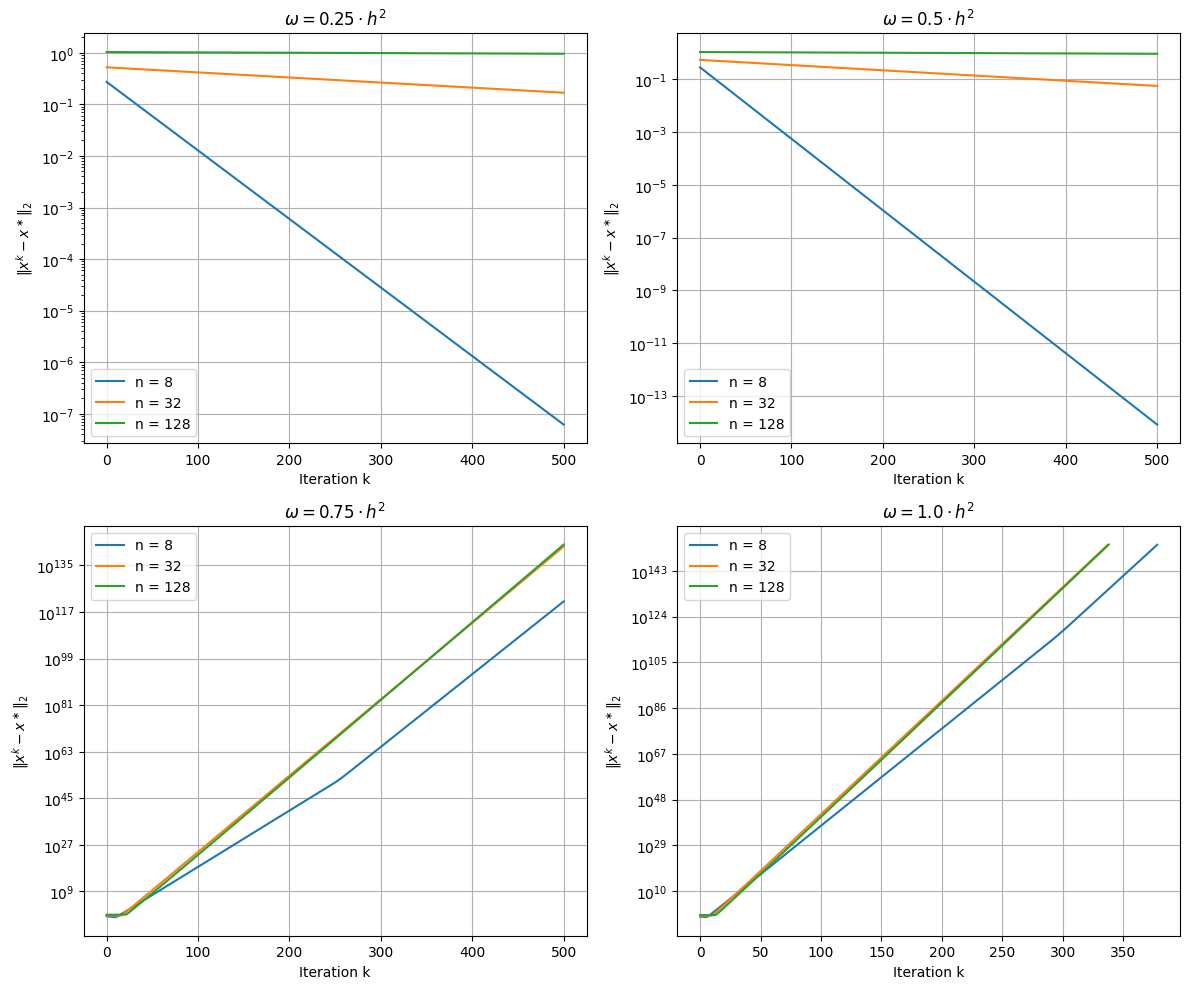

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def assemble(n):
    h = 1.0 / (n + 1)
    A = (1.0 / h**2) * (
        2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)
    )
    b = np.ones(n)
    return A, b

def Richardson(A, b, x0, w, k, x_exact):
    x = x0.copy()
    errors = np.zeros(k + 1)
    errors[0] = np.linalg.norm(x - x_exact)

    for j in range(1, k + 1):
        x = x + w * (b - A @ x)
        errors[j] = np.linalg.norm(x - x_exact)

    return x, errors


ns = [8, 32, 128]
k = 500

# Dummy h für Definition der Omegas (wird später pro n neu gesetzt)
h_dummy = 1.0 / (128 + 1)

omega_factors = [1/4, 1/2, 3/4, 1.0]  # multipliziert mit h^2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, factor in enumerate(omega_factors):
    ax = axes[idx // 2, idx % 2]

    for n in ns:
        A, b = assemble(n)
        h = 1.0 / (n + 1)
        w = factor * h**2

        x_exact = np.linalg.solve(A, b)
        x0 = np.zeros(n)

        _, errors = Richardson(A, b, x0, w, k, x_exact)

        ax.semilogy(range(k + 1), errors, label=f"n = {n}")

    ax.set_title(rf"$\omega = {factor} \cdot h^2$")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel(r"$\|x^k - x^\ast\|_2$")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## 2. Analysis of the Richardson Method

### Iterationsmatrix

Die Richardson-Iteration lautet:
$$
x^{k+1} = x^k + \omega (b - A x^k).
$$

Damit ergibt sich die Iterationsmatrix:
$$
I - \omega A.
$$

Da
$$
A = \frac{1}{h^2} T,
$$
wobei $T$ die tridiagonale Matrix mit $2$ auf der Diagonale und $-1$ auf den Nebendiagonalen ist, folgt:

$$
I - \omega A = I - \frac{h^2}{2} \cdot \frac{1}{h^2} T = I - \frac{1}{2} T.
$$

---

### Eigenwerte der Iterationsmatrix

Die Eigenwerte der Iterationsmatrix sind
$$
\mu_j = 1 - \omega \lambda_j.
$$

---

### Konvergenzbedingung

Das Richardson-Verfahren konvergiert genau dann, wenn
$$
\rho(I - \omega A) = \max_j |\mu_j| < 1,
$$
also
$$
|1 - \omega \lambda_j| < 1 \quad \text{für alle } j.
$$

Dies ist äquivalent zu
$$
0 < \omega < \frac{2}{\lambda_{\max}(A)}.
$$

Mit
$$
\lambda_{\max}(A) = \frac{4}{h^2} \sin^2\!\left(\frac{n\pi}{2(n+1)}\right)
\approx \frac{4}{h^2}
$$
folgt näherungsweise
$$
\omega < \frac{h^2}{2}.
$$

---

### Interpretation der Wahl von $\omega$

- **$\omega < \frac{h^2}{2}$:**  
  → Verfahren ist stabil und konvergiert

- **$\omega \approx \frac{h^2}{2}$:**  
  → nahe an optimaler Wahl, schnellste Konvergenz

- **$\omega > \frac{h^2}{2}$:**  
  → Instabilität und Divergenz

---

### Spezialfall: $\omega = \frac{h^2}{2}$

Wir wählen
$$
\omega = \frac{h^2}{2}, \qquad h = \frac{1}{n+1}.
$$

Dann gilt
$$
I - \omega A 
= I - \frac{h^2}{2} \cdot \frac{1}{h^2} T 
= I - \frac{1}{2} T.
$$

Die Eigenwerte werden zu
$$
\mu_j = 1 - 2 \sin^2\!\left(\frac{j\pi}{2(n+1)}\right)
= \cos\!\left(\frac{j\pi}{n+1}\right).
$$

---

### Spektralradius

Damit ist
$$
\rho(I - \omega A) 
= \max_j |\mu_j| 
= \cos\!\left(\frac{\pi}{n+1}\right).
$$

---

### Beobachtungen für verschiedene $n$

- **Für $n = 8$:**
  $$
  \rho \approx \cos(\pi/9) \approx 0.94
  $$
  → merkliche Konvergenz

- **Für $n = 32$:**
  $$
  \rho \approx \cos(\pi/33) \approx 0.995
  $$
  → sehr langsame Konvergenz

- **Für $n = 128$:**
  $$
  \rho \approx \cos(\pi/129) \approx 0.9997
  $$
  → praktisch Stillstand bei 500 Iterationen

---

### Schlussfolgerung

Für wachsendes $n$ gilt
$$
\rho(I - \omega A) \to 1 \quad \text{für } n \to \infty.
$$

Damit wird die Konvergenz des Richardson-Verfahrens immer langsamer.

👉 Das erklärt, warum die Fehlerkurven für große $n$ im Plot nahezu konstant bleiben und das Verfahren für feine Gitter ineffizient ist.

## Exercise 2 (Jacobi and Gauss-Seidel)
1. Implement the Jacobi and Gauss-Seidel methods: `val = Jacobi(A, b, x0, k)` and `val = GaussSeidel(A, b, x0, k)`.
2. Compare all three methods (Richardson, Jacobi, GS) for $n \in \{8, 32, 128\}$ and $k=500$. Plot the errors.


## Jacobi Method

### 1. Mathematical Formulation (Splitting Approach)

Let $\mathbf{A} \in \mathbb{R}^{n \times n}$ be regular and define  
$\mathbf{D} \in \mathbb{R}^{n \times n}$ by
$$
D_{ij} = A_{ij} \delta_{ij},
$$
i.e., $\mathbf{D}$ is the diagonal of $\mathbf{A}$.

Assume that $\mathbf{D}$ is invertible, i.e., $A_{ii} \neq 0$ for all $i=1,\dots,n$.

---

### Splitting

We write
$$
\mathbf{A} = \mathbf{D} + (\mathbf{A} - \mathbf{D}).
$$

Define
$$
\mathbf{G} := \mathbf{D}, \qquad \mathbf{H} := -(\mathbf{A} - \mathbf{D}).
$$

Then
$$
\mathbf{A} = \mathbf{G} - \mathbf{H}.
$$

---

### Iterative Scheme

The Jacobi iteration is defined via:

- Solve
$$
\mathbf{D}\,\delta_k = \mathbf{b} - \mathbf{A}\mathbf{x}_k
$$

- Update
$$
\mathbf{x}_{k+1} := \mathbf{x}_k + \delta_k
$$

---

### Explicit Form

Substituting $\delta_k$ gives
$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k + \mathbf{D}^{-1}(\mathbf{b} - \mathbf{A}\mathbf{x}_k).
$$

Using $\mathbf{A} = \mathbf{D} + (\mathbf{A}-\mathbf{D})$, we obtain
$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k + \mathbf{D}^{-1}\big(\mathbf{b} - \mathbf{D}\mathbf{x}_k - (\mathbf{A}-\mathbf{D})\mathbf{x}_k\big).
$$

Rearranging yields
$$
\mathbf{x}_{k+1}
=
\mathbf{D}^{-1}\left(\mathbf{b} - (\mathbf{A}-\mathbf{D})\mathbf{x}_k\right).
$$

---

### Component-wise Form

Using upper indices for the iteration and lower indices for components, we obtain
$$
x_i^{k+1}
=
x_i^k + \frac{1}{A_{ii}}\left(b_i - \sum_{j=1}^n A_{ij} x_j^k\right),
\qquad i=1,\dots,n.
$$

Equivalently,
$$
x_i^{k+1}
=
\frac{1}{A_{ii}}\left(b_i - \sum_{j \ne i} A_{ij} x_j^k\right).
$$


---

### Interpretation

- Each component is computed **independently**.
- Only values from the previous iterate $\mathbf{x}_k$ are used.
- No newly computed values are reused within the same iteration.
- This makes the Jacobi method naturally **parallelizable**, but leads to slower information propagation compared to Gauss–Seidel.

---

### Convergence

The method converges if
$$
\rho(\mathbf{M}_{Jac}) < 1.
$$

For the discrete 1D Poisson problem:
- The Jacobi method is convergent.
- However, it converges more slowly than Gauss–Seidel.
- Moreover,
$$
\rho(\mathbf{M}_{Jac}) \to 1 \quad \text{as } n \to \infty,
$$
which implies very slow convergence for large systems.

## Gauss–Seidel Method

### 1. Mathematical Formulation (Splitting Approach)

Let $\mathbf{A} \in \mathbb{R}^{n \times n}$ be regular and write
$$
\mathbf{A} = \mathbf{L} + \mathbf{D} + \mathbf{U},
$$
where:
- $\mathbf{D}$ is the diagonal of $\mathbf{A}$,
- $\mathbf{L}$ is the strictly lower triangular part,
- $\mathbf{U}$ is the strictly upper triangular part.

Assume that $\mathbf{D}$ (and hence $\mathbf{D}+\mathbf{L}$) is invertible.

---

### Splitting

We consider the splitting
$$
\mathbf{A} = (\mathbf{D} + \mathbf{L}) + \mathbf{U}.
$$

Define
$$
\mathbf{G} := \mathbf{D} + \mathbf{L}, \qquad \mathbf{H} := -\mathbf{U}.
$$

Then
$$
\mathbf{A} = \mathbf{G} - \mathbf{H}.
$$

---

### Iterative Scheme

The Gauss–Seidel iteration is defined via:

- Solve
$$
(\mathbf{D} + \mathbf{L}) \, \delta_k = \mathbf{b} - \mathbf{A}\mathbf{x}_k
$$

- Update
$$
\mathbf{x}_{k+1} := \mathbf{x}_k + \delta_k
$$

---

### Explicit Form

Substituting $\delta_k$ gives
$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k + (\mathbf{D}+\mathbf{L})^{-1}(\mathbf{b} - \mathbf{A}\mathbf{x}_k).
$$

Using $\mathbf{A} = \mathbf{D} + \mathbf{L} + \mathbf{U}$, we obtain
$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k + (\mathbf{D}+\mathbf{L})^{-1}
\big(\mathbf{b} - (\mathbf{D} + \mathbf{L} + \mathbf{U})\mathbf{x}_k\big).
$$

Rearranging step by step:
$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k + (\mathbf{D}+\mathbf{L})^{-1}
\big(\mathbf{b} - (\mathbf{D}+\mathbf{L})\mathbf{x}_k - \mathbf{U}\mathbf{x}_k\big)
$$

$$
=
\mathbf{x}_k
+
(\mathbf{D}+\mathbf{L})^{-1}(\mathbf{b} - (\mathbf{D}+\mathbf{L})\mathbf{x}_k)
-
(\mathbf{D}+\mathbf{L})^{-1}\mathbf{U}\mathbf{x}_k
$$

Using
$$
\mathbf{x}_k + (\mathbf{D}+\mathbf{L})^{-1}(\mathbf{b} - (\mathbf{D}+\mathbf{L})\mathbf{x}_k)
= (\mathbf{D}+\mathbf{L})^{-1}\mathbf{b},
$$

we finally obtain
$$
\mathbf{x}_{k+1}
=
(\mathbf{D}+\mathbf{L})^{-1}\left(\mathbf{b} - \mathbf{U}\mathbf{x}_k\right).
$$

---

### Component-wise Form

Using upper indices for iterations and lower indices for components, we obtain

$$
x_i^{k+1}
=
x_i^k
+
\frac{1}{A_{ii}}
\left(
b_i
-
\sum_{j<i} A_{ij} x_j^{k+1}
-
\sum_{j \ge i} A_{ij} x_j^k
\right),
\qquad i=1,\dots,n.
$$


Equivalently,


$$
x_i^{k+1}
=
\frac{1}{A_{ii}}
\left(
b_i
-
\sum_{j<i} A_{ij} x_j^{k+1}
-
\sum_{j>i} A_{ij} x_j^k
\right),
\qquad i=1,\dots,n.
$$

---

### Interpretation

- The components are updated **sequentially**.
- Newly computed values $x_j^{k+1}$ are used immediately for $j<i$.
- This leads to faster propagation of information compared to Jacobi.

---

### Convergence

The method converges if
$$
\rho(\mathbf{M}_{GS}) < 1.
$$

For the discrete 1D Poisson problem:
- Gauss–Seidel is convergent.
- It typically converges faster than Jacobi.
- However,
$$
\rho(\mathbf{M}_{GS}) \to 1 \quad \text{as } n \to \infty,
$$
so convergence deteriorates for large systems.

In [3]:
import numpy as np

def Jacobi(A, b, x0, k, x_exact=None):
    D = np.diag(A)                 # diagonal entries of A
    R = A - np.diagflat(D)         # strictly off-diagonal part = A - D

    x = x0.copy()
    errors = np.zeros(k + 1)

    if x_exact is not None:
        errors[0] = np.linalg.norm(x - x_exact)

    for m in range(1, k + 1):
        x = (b - R @ x) / D

        if x_exact is not None:
            errors[m] = np.linalg.norm(x - x_exact)

    return x, errors

The term `R @ x` corresponds to the sum
$$
\sum_{j \ne i} A_{ij} x_j,
$$
since $R = A - \mathrm{diag}(A)$ contains only the off-diagonal entries of $A$.

In [4]:
import numpy as np

def GaussSeidel(A, b, x0, k, x_exact=None):
    n = len(b)
    x = x0.copy()
    errors = np.zeros(k + 1)

    if x_exact is not None:
        errors[0] = np.linalg.norm(x - x_exact)

    for m in range(1, k + 1):
        x_old = x.copy()

        for i in range(n):
            sum1 = 0.0
            for j in range(i):
                sum1 += A[i, j] * x[j]          # new values x_j^(k+1), j < i

            sum2 = 0.0
            for j in range(i + 1, n):
                sum2 += A[i, j] * x_old[j]      # old values x_j^k, j > i

            x[i] = (b[i] - sum1 - sum2) / A[i, i]

        if x_exact is not None:
            errors[m] = np.linalg.norm(x - x_exact)

    return x, errors

In the Gauss–Seidel method, the update is performed sequentially.

For each component $x_i^{k+1}$:
- the values $x_j^{k+1}$ for $j<i$ are already updated and reused,
- the values $x_j^k$ for $j>i$ are still from the previous iteration.

This is why the implementation requires a loop and cannot be written as a simple matrix-vector product.

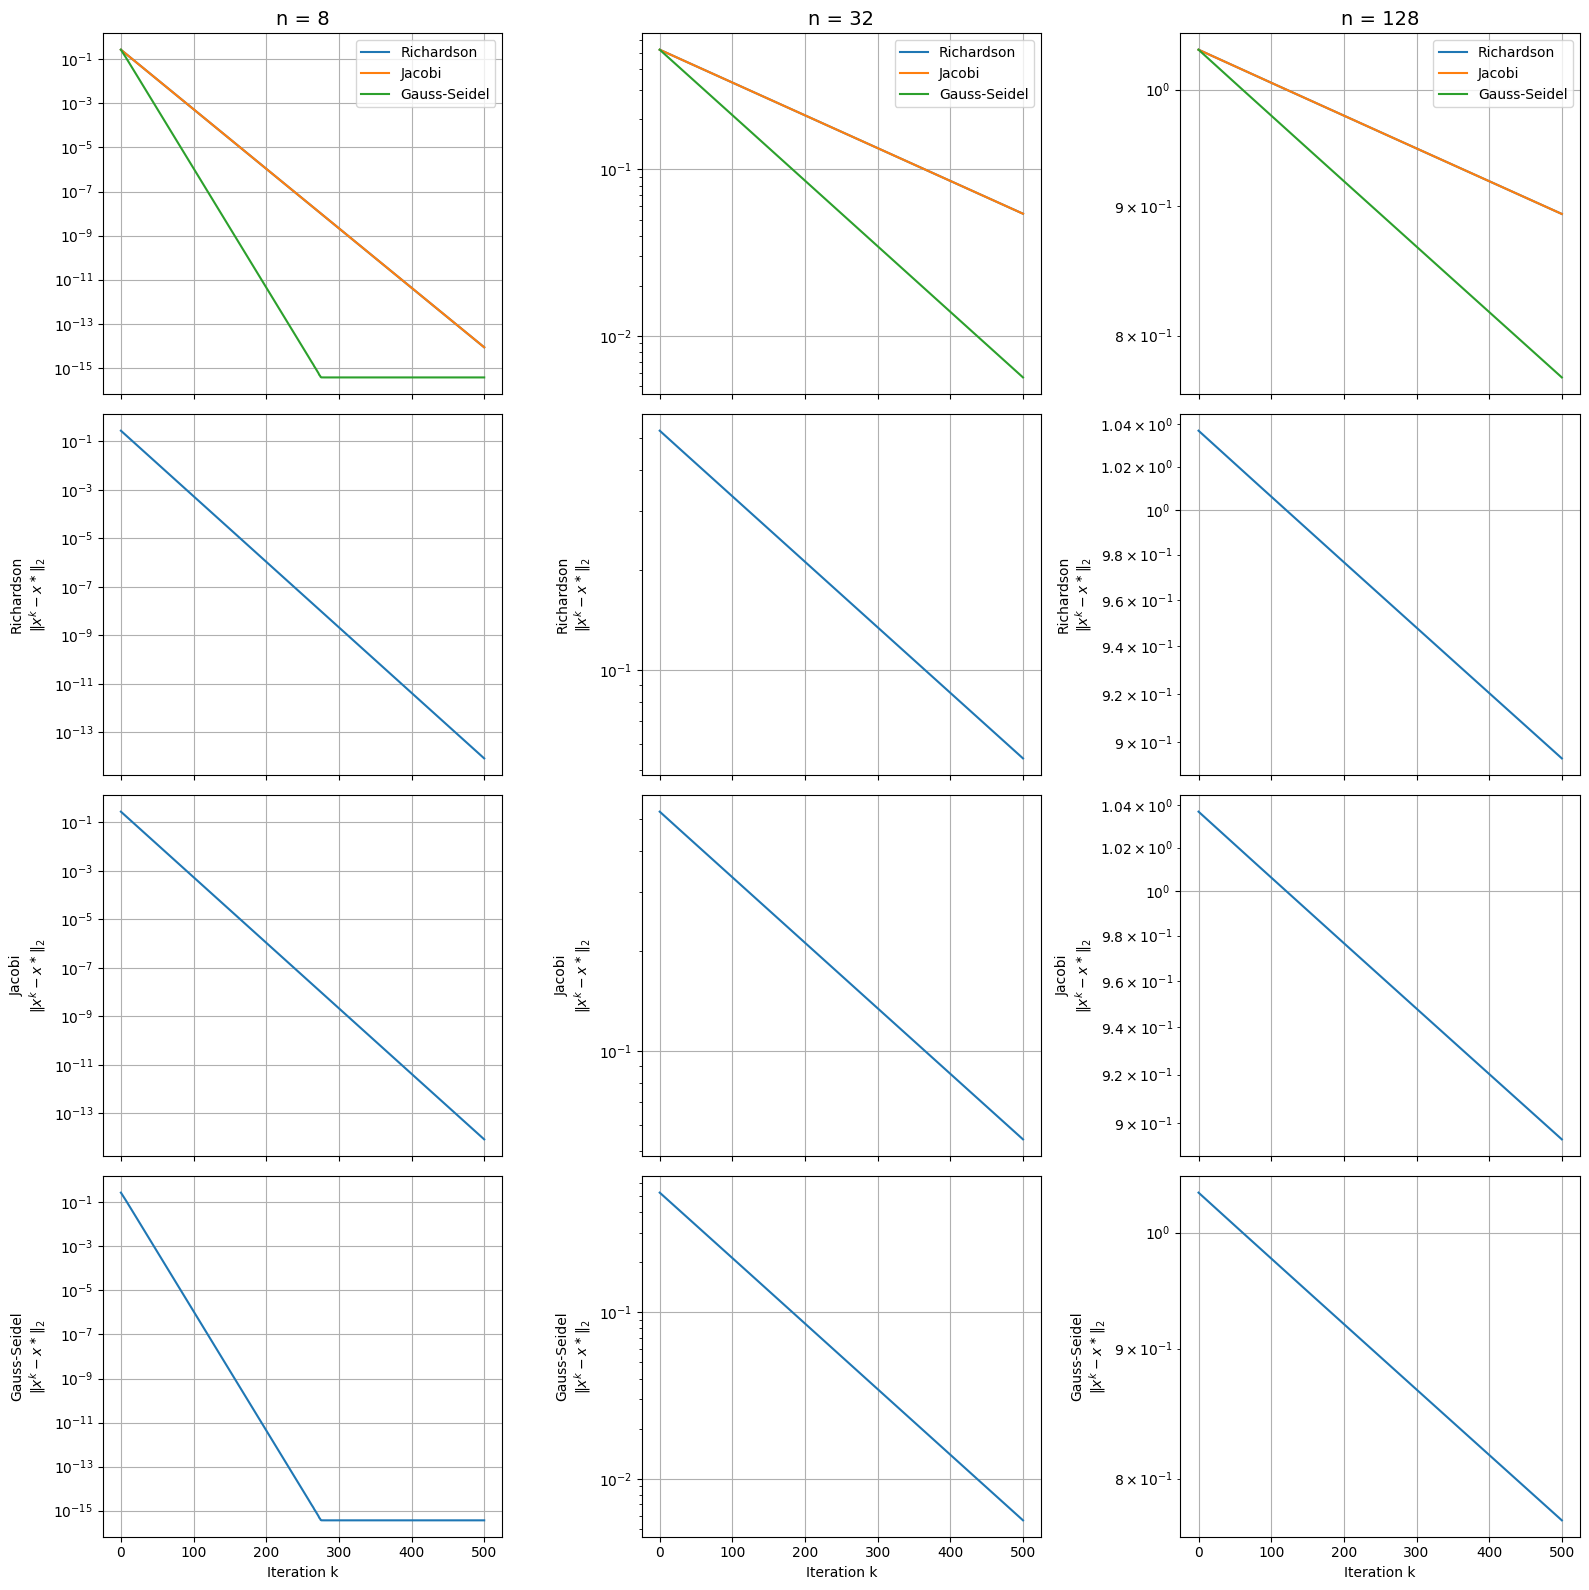

In [5]:
import numpy as np
import matplotlib.pyplot as plt

ns = [8, 32, 128]
k = 500

fig, axes = plt.subplots(4, 3, figsize=(16, 16), sharex=True)

method_names = ["Richardson", "Jacobi", "Gauss-Seidel"]

for col, n in enumerate(ns):
    A, b = assemble(n)
    h = 1.0 / (n + 1)
    w = h**2 / 2

    x_exact = np.linalg.solve(A, b)
    x0 = np.zeros(n)

    _, err_rich = Richardson(A, b, x0, w, k, x_exact)
    _, err_jac  = Jacobi(A, b, x0, k, x_exact)
    _, err_gs   = GaussSeidel(A, b, x0, k, x_exact)

    # --- Row 0: ALL METHODS TOGETHER ---
    ax = axes[0, col]
    ax.semilogy(range(k + 1), err_rich, label="Richardson")
    ax.semilogy(range(k + 1), err_jac,  label="Jacobi")
    ax.semilogy(range(k + 1), err_gs,   label="Gauss-Seidel")

    ax.set_title(f"n = {n}", fontsize=14)
    ax.grid(True)
    ax.legend()

    # --- Row 1: Richardson ---
    ax = axes[1, col]
    ax.semilogy(range(k + 1), err_rich)
    ax.set_ylabel("Richardson\n" + r"$\|x^k - x^\ast\|_2$")
    ax.grid(True)

    # --- Row 2: Jacobi ---
    ax = axes[2, col]
    ax.semilogy(range(k + 1), err_jac)
    ax.set_ylabel("Jacobi\n" + r"$\|x^k - x^\ast\|_2$")
    ax.grid(True)

    # --- Row 3: Gauss-Seidel ---
    ax = axes[3, col]
    ax.semilogy(range(k + 1), err_gs)
    ax.set_ylabel("Gauss-Seidel\n" + r"$\|x^k - x^\ast\|_2$")
    ax.set_xlabel("Iteration k")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Convergence and Comparison of Jacobi and Gauss–Seidel

### Lemma (Diagonal dominance and irreducibility)

Let $\mathbf{A} \in \mathbb{R}^{n \times n}$ be diagonally dominant and irreducible.
Then the Jacobi and Gauss–Seidel iterations are well-defined and convergent.

---

### Application to the model problem

For the discrete 1D Poisson problem, the matrix $\mathbf{A}$ has the form
$$
A = \frac{1}{h^2}
\begin{pmatrix}
2 & -1 \\
-1 & 2 & -1 \\
& \ddots & \ddots & \ddots \\
&& -1 & 2
\end{pmatrix}.
$$

- For all rows:
$$
|A_{ii}| = \frac{2}{h^2}, \qquad \sum_{j \ne i} |A_{ij}| \le \frac{2}{h^2}.
$$

- For the first and last rows:
$$
|A_{ii}| = \frac{2}{h^2} > \frac{1}{h^2} = \sum_{j \ne i} |A_{ij}|.
$$

Hence, $\mathbf{A}$ is diagonally dominant, and strictly diagonally dominant in at least one row.

Moreover, the matrix is irreducible due to its tridiagonal structure.

Therefore, the lemma applies, and both Jacobi and Gauss–Seidel methods converge.

---

### Stein–Rosenberg Theorem

Let $\mathbf{A} = (a_{ij})$ with
$$
a_{ii} > 0, \qquad a_{ij} \le 0 \quad \text{for } i \ne j.
$$

Let $\mathbf{T}_J$ and $\mathbf{T}_{GS}$ denote the iteration matrices of Jacobi and Gauss–Seidel.

Then exactly one of the following holds:

1. $\rho(\mathbf{T}_J) = \rho(\mathbf{T}_{GS}) = 0$
2. $0 < \rho(\mathbf{T}_{GS}) < \rho(\mathbf{T}_J) < 1$
3. $\rho(\mathbf{T}_J) = \rho(\mathbf{T}_{GS}) = 1$
4. $1 < \rho(\mathbf{T}_J) < \rho(\mathbf{T}_{GS})$

---

### Application of Stein–Rosenberg

The matrix $\mathbf{A}$ satisfies:

- $a_{ii} > 0$
- $a_{ij} \le 0$ for $i \ne j$

Thus, the Stein–Rosenberg theorem applies.

From the previous lemma, both methods are convergent, hence
$$
\rho(\mathbf{T}_J) < 1.
$$

Therefore, only case (2) is possible:
$$
0 < \rho(\mathbf{T}_{GS}) < \rho(\mathbf{T}_J) < 1.
$$

---

### Conclusion

Gauss–Seidel has a strictly smaller spectral radius than Jacobi and therefore converges faster.

This theoretical result is consistent with the observed numerical behavior.

## Relation between Richardson and Jacobi

The Richardson iteration is given by
$$
\mathbf{x}^{k+1} = \mathbf{x}^k + \omega \bigl(\mathbf{b} - \mathbf{A}\mathbf{x}^k\bigr).
$$

For the model problem, the matrix has the form
$$
\mathbf{A} = \frac{1}{h^2}\mathbf{T},
$$
where $\mathbf{T}$ is the tridiagonal matrix with diagonal entries $2$ and off-diagonal entries $-1$.

We now choose
$$
\omega = \frac{h^2}{2}.
$$

Then the Richardson iteration becomes
$$
\mathbf{x}^{k+1}
=
\mathbf{x}^k + \frac{h^2}{2}\left(\mathbf{b} - \frac{1}{h^2}\mathbf{T}\mathbf{x}^k\right)
=
\mathbf{x}^k + \frac{h^2}{2}\mathbf{b} - \frac{1}{2}\mathbf{T}\mathbf{x}^k.
$$

Using
$$
\mathbf{T} = 2\mathbf{I} + \mathbf{L} + \mathbf{U},
$$
we obtain
$$
\mathbf{x}^{k+1}
=
\mathbf{x}^k + \frac{h^2}{2}\mathbf{b}
-\frac{1}{2}(2\mathbf{I}+\mathbf{L}+\mathbf{U})\mathbf{x}^k.
$$

Hence
$$
\mathbf{x}^{k+1}
=
\frac{h^2}{2}\mathbf{b} - \frac{1}{2}(\mathbf{L}+\mathbf{U})\mathbf{x}^k.
$$

---

### Jacobi method

For the Jacobi method, we split
$$
\mathbf{A} = \mathbf{D} + (\mathbf{A}-\mathbf{D}),
$$
where
$$
\mathbf{D} = \frac{2}{h^2}\mathbf{I}.
$$

Thus,
$$
\mathbf{D}^{-1} = \frac{h^2}{2}\mathbf{I}.
$$

The Jacobi iteration is
$$
\mathbf{x}^{k+1}
=
\mathbf{D}^{-1}\bigl(\mathbf{b} - (\mathbf{A}-\mathbf{D})\mathbf{x}^k\bigr).
$$

Since
$$
\mathbf{A}-\mathbf{D}
=
\frac{1}{h^2}(\mathbf{L}+\mathbf{U}),
$$
it follows that
$$
\mathbf{x}^{k+1}
=
\frac{h^2}{2}\left(\mathbf{b} - \frac{1}{h^2}(\mathbf{L}+\mathbf{U})\mathbf{x}^k\right)
=
\frac{h^2}{2}\mathbf{b} - \frac{1}{2}(\mathbf{L}+\mathbf{U})\mathbf{x}^k.
$$

---

### Conclusion

Thus, for the choice
$$
\omega = \frac{h^2}{2},
$$
the Richardson iteration and the Jacobi iteration are identical.

In particular, they have the same iteration matrix and therefore exactly the same convergence behavior for the model problem.

## Exercise 3 (Stopping Criterion)
Instead of a fixed number of steps $k$, use a tolerance $\tau > 0$ such that $\|x - x_k\|_2 < \tau$.
1. Derive a computable **a-posteriori error estimator** $\eta_k$ such that $\|x - x_k\| \le C \eta_k$.
2. Modify your implementations and test for $\tau \in \{10^{-3}, 10^{-5}, 10^{-7}\}$.


## A-posteriori error estimate via Banach's fixed point theorem

### Banach fixed point theorem

Let $(X,\|\cdot\|)$ be a Banach space and let $\Phi : X \to X$ satisfy
$$
\|\Phi(x) - \Phi(y)\| \le q \|x-y\| \quad \forall x,y \in X,
$$
for some constant $0 < q < 1$.

Then there exists a unique fixed point $x^\ast \in X$ such that
$$
\Phi(x^\ast) = x^\ast,
$$
and the iterates defined by
$$
x_{k+1} := \Phi(x_k)
$$
converge to $x^\ast$.

Moreover, the following estimates hold:

- **Contraction of the error:**
$$
\|x^\ast - x_{k+1}\| \le q \|x^\ast - x_k\|
$$

- **A-posteriori error estimate:**
$$
\|x^\ast - x_{k+1}\|
\le
\frac{q}{1-q} \|x_{k+1} - x_k\|
$$

---

### Application to iterative methods

For linear iterative methods of the form
$$
x_{k+1} = M x_k + N b,
$$
we define the iteration mapping
$$
\Phi(x) = Mx + Nb.
$$

Then
$$
\Phi(x) - \Phi(y) = M(x-y),
$$
and hence
$$
\|\Phi(x) - \Phi(y)\| \le \|M\| \|x-y\|.
$$

Thus, if $\|M\| < 1$, the mapping $\Phi$ is a contraction with
$$
q = \|M\|.
$$

Since the iteration matrix $M$ satisfies $\rho(M) < 1$, 
there exists a matrix norm such that $\|M\| < 1$. 
Hence, the iteration is a contraction, and Banach's fixed point theorem applies.

---

### Error estimator

Let $x^\ast = x$ denote the exact solution of the system.

From the a-posteriori estimate, we obtain
$$
\|x - x_{k+1}\|
\le
\frac{q}{1-q} \|x_{k+1} - x_k\|.
$$

We therefore define the computable error estimator
$$
\eta_k := \|x_k - x_{k-1}\|.
$$

Hence,
$$
\|x - x_k\| \le C \eta_k,
\qquad
C = \frac{q}{1-q}.
$$

---

### Stopping criterion

We stop the iteration as soon as
$$
\eta_k < \tau,
$$
which ensures that the true error is controlled up to the constant $C$.

Strictly speaking, the stopping criterion ensures
$$
\|x - x_k\| \le C \tau,
$$
i.e., the true error is controlled up to the constant $C$.

In [6]:
def assemble(n):
    h = 1.0 / (n + 1)
    A = (1.0 / h**2) * (2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1))
    b = np.ones(n)
    return A, b

In [7]:
def Richardson_stop(A, b, x0, w, tau, maxit=100000):
    x_old = x0.copy()
    x_new = x_old + w * (b - A @ x_old)
    k = 1

    while np.linalg.norm(x_new - x_old) >= tau and k < maxit:
        x_old = x_new.copy()
        x_new = x_old + w * (b - A @ x_old)
        k += 1

    return x_new, k

In [8]:
def Jacobi_stop(A, b, x0, tau, maxit=100000):
    D = np.diag(A)
    R = A - np.diagflat(D)

    x_old = x0.copy()
    x_new = (b - R @ x_old) / D
    k = 1

    while np.linalg.norm(x_new - x_old) >= tau and k < maxit:
        x_old = x_new.copy()
        x_new = (b - R @ x_old) / D
        k += 1

    return x_new, k

In [9]:
def GaussSeidel_stop(A, b, x0, tau, maxit=100000):
    n = len(b)
    x_old = x0.copy()
    x_new = x0.copy()
    k = 0

    while k < maxit:
        x_prev = x_new.copy()

        for i in range(n):
            sum1 = np.dot(A[i, :i], x_new[:i])
            sum2 = np.dot(A[i, i+1:], x_prev[i+1:])
            x_new[i] = (b[i] - sum1 - sum2) / A[i, i]

        k += 1

        if np.linalg.norm(x_new - x_prev) < tau:
            break

    return x_new, k

In [10]:
ns = [8, 32, 128]
taus = [1e-3, 1e-5, 1e-7]

for n in ns:
    A, b = assemble(n)
    h = 1.0 / (n + 1)
    w = h**2 / 2
    x0 = np.zeros(n)
    x_exact = np.linalg.solve(A, b)

    print(f"\n===== n = {n} =====")

    for tau in taus:
        x_rich, k_rich = Richardson_stop(A, b, x0, w, tau)
        x_jac,  k_jac  = Jacobi_stop(A, b, x0, tau)
        x_gs,   k_gs   = GaussSeidel_stop(A, b, x0, tau)

        err_rich = np.linalg.norm(x_exact - x_rich)
        err_jac  = np.linalg.norm(x_exact - x_jac)
        err_gs   = np.linalg.norm(x_exact - x_gs)

        print(f"\ntau = {tau:.0e}")
        print(f"Richardson : iterations = {k_rich:6d}, final exact error = {err_rich:.6e}")
        print(f"Jacobi     : iterations = {k_jac:6d}, final exact error = {err_jac:.6e}")
        print(f"Gauss-Seidel: iterations = {k_gs:6d}, final exact error = {err_gs:.6e}")


===== n = 8 =====

tau = 1e-03
Richardson : iterations =     47, final exact error = 1.470696e-02
Jacobi     : iterations =     47, final exact error = 1.470696e-02
Gauss-Seidel: iterations =     30, final exact error = 6.872979e-03

tau = 1e-05
Richardson : iterations =    121, final exact error = 1.473918e-04
Jacobi     : iterations =    121, final exact error = 1.473918e-04
Gauss-Seidel: iterations =     67, final exact error = 6.888040e-05

tau = 1e-07
Richardson : iterations =    195, final exact error = 1.477147e-06
Jacobi     : iterations =    195, final exact error = 1.477147e-06
Gauss-Seidel: iterations =    104, final exact error = 6.903130e-07

===== n = 32 =====

tau = 1e-03
Richardson : iterations =    192, final exact error = 2.192417e-01
Jacobi     : iterations =    192, final exact error = 2.192417e-01
Gauss-Seidel: iterations =    173, final exact error = 1.093715e-01

tau = 1e-05
Richardson : iterations =   1207, final exact error = 2.189644e-03
Jacobi     : iteratio

In [11]:
import pandas as pd

results = []

ns = [8, 32, 128]
taus = [1e-3, 1e-5, 1e-7]

for n in ns:
    A, b = assemble(n)
    h = 1.0 / (n + 1)
    w = h**2 / 2
    x0 = np.zeros(n)
    x_exact = np.linalg.solve(A, b)

    for tau in taus:
        x_rich, k_rich = Richardson_stop(A, b, x0, w, tau)
        x_jac,  k_jac  = Jacobi_stop(A, b, x0, tau)
        x_gs,   k_gs   = GaussSeidel_stop(A, b, x0, tau)

        results.append({
            "Method": "Richardson",
            "n": n,
            "tau": tau,
            "Iterations": k_rich,
            "Final Error": np.linalg.norm(x_exact - x_rich)
        })

        results.append({
            "Method": "Jacobi",
            "n": n,
            "tau": tau,
            "Iterations": k_jac,
            "Final Error": np.linalg.norm(x_exact - x_jac)
        })

        results.append({
            "Method": "Gauss-Seidel",
            "n": n,
            "tau": tau,
            "Iterations": k_gs,
            "Final Error": np.linalg.norm(x_exact - x_gs)
        })

df = pd.DataFrame(results)

df

,Method,n,tau,Iterations,Final Error
0,Richardson,8,1.000000e-03,47,1.470696e-02
1,Jacobi,8,1.000000e-03,47,1.470696e-02
2,Gauss-Seidel,8,1.000000e-03,30,6.872979e-03
3,Richardson,8,1.000000e-05,121,1.473918e-04
4,Jacobi,8,1.000000e-05,121,1.473918e-04
5,Gauss-Seidel,8,1.000000e-05,67,6.888040e-05
6,Richardson,8,1.000000e-07,195,1.477147e-06
7,Jacobi,8,1.000000e-07,195,1.477147e-06
8,Gauss-Seidel,8,1.000000e-07,104,6.903130e-07
9,Richardson,32,1.000000e-03,192,2.192417e-01


In [12]:
import matplotlib.pyplot as plt

def run_with_history(method, A, b, x0, tau, w=None, maxit=100000):
    x = x0.copy()
    errors = []
    steps = []

    x_exact = np.linalg.solve(A, b)

    for k in range(maxit):
        err = np.linalg.norm(x - x_exact)
        errors.append(err)
        steps.append(k)

        if k > 0 and np.linalg.norm(x - x_prev) < tau:
            break

        x_prev = x.copy()

        if method == "richardson":
            x = x + w * (b - A @ x)

        elif method == "jacobi":
            D = np.diag(A)
            R = A - np.diagflat(D)
            x = (b - R @ x) / D

        elif method == "gs":
            n = len(b)
            x_new = x.copy()
            for i in range(n):
                sum1 = np.dot(A[i, :i], x_new[:i])
                sum2 = np.dot(A[i, i+1:], x[i+1:])
                x_new[i] = (b[i] - sum1 - sum2) / A[i, i]
            x = x_new

    return steps, errors

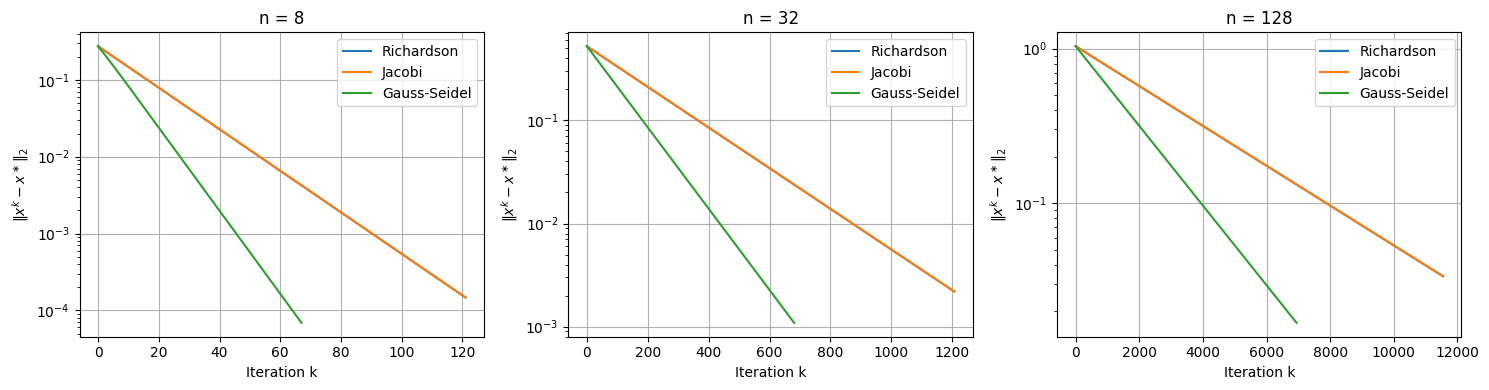

In [13]:
ns = [8, 32, 128]
tau = 1e-5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, n in enumerate(ns):
    A, b = assemble(n)
    h = 1.0 / (n + 1)
    w = h**2 / 2
    x0 = np.zeros(n)

    ax = axes[i]

    steps_r, err_r = run_with_history("richardson", A, b, x0, tau, w=w)
    steps_j, err_j = run_with_history("jacobi", A, b, x0, tau)
    steps_g, err_g = run_with_history("gs", A, b, x0, tau)

    ax.semilogy(steps_r, err_r, label="Richardson")
    ax.semilogy(steps_j, err_j, label="Jacobi")
    ax.semilogy(steps_g, err_g, label="Gauss-Seidel")

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel(r"$\|x^k - x^\ast\|_2$")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Observation

The error decreases approximately linearly on the logarithmic scale for all methods, which indicates linear convergence.

For all problem sizes, the Richardson method with $\omega = h^2/2$ and the Jacobi method show identical behavior. This confirms that both methods coincide for this choice of $\omega$.

The Gauss–Seidel method converges significantly faster than both Richardson and Jacobi. This is consistent with the theoretical result that the spectral radius of the Gauss–Seidel iteration matrix is smaller than that of Jacobi.

Moreover, the convergence becomes slower as the problem size $n$ increases. In particular, for $n = 128$, all methods converge very slowly. This reflects the fact that the spectral radius approaches $1$ for finer discretizations.

Consequently, the number of iterations required to reach a prescribed tolerance increases significantly with $n$, showing that these basic iterative methods are inefficient for large systems.

## Exercise 4 (Contraction Factor)
For $n \in \{8, 32, 128\}$ and $k=150$, compute and plot the experimental contraction factors:
$$\frac{\|x - x_{k+1}\|_2}{\|x - x_k\|_2}$$
What do you observe for Jacobi vs. Gauss-Seidel?


In [14]:
def contraction_factors(errors):
    return errors[1:] / errors[:-1]

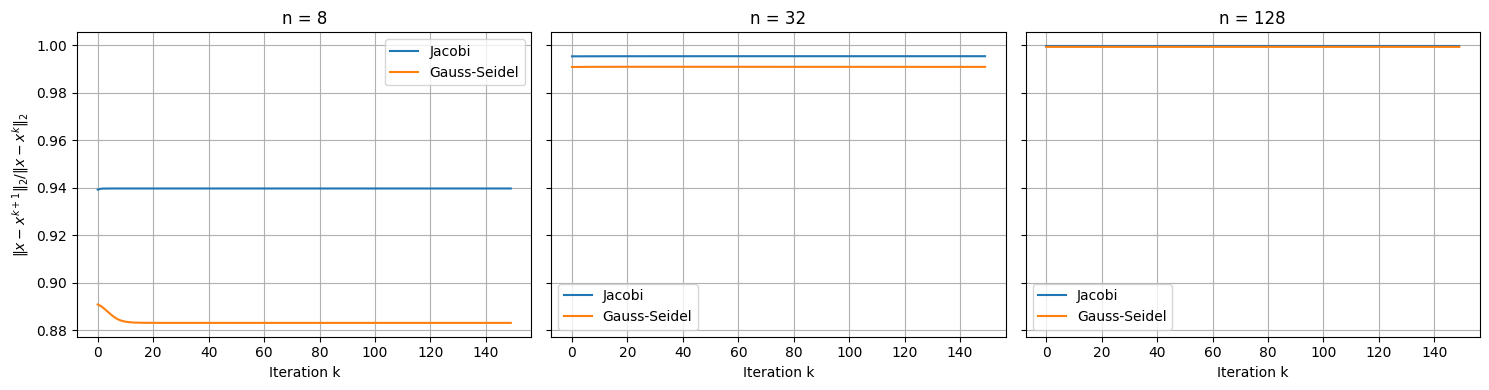

In [15]:
ns = [8, 32, 128]
k = 150

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, n in enumerate(ns):
    A, b = assemble(n)
    x0 = np.zeros(n)
    x_exact = np.linalg.solve(A, b)

    _, err_jac = Jacobi(A, b, x0, k, x_exact=x_exact)
    _, err_gs  = GaussSeidel(A, b, x0, k, x_exact=x_exact)

    q_jac = contraction_factors(err_jac)
    q_gs  = contraction_factors(err_gs)

    ax = axes[idx]
    ax.plot(range(k), q_jac, label="Jacobi")
    ax.plot(range(k), q_gs, label="Gauss-Seidel")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Iteration k")
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel(r"$\|x-x^{k+1}\|_2 / \|x-x^k\|_2$")
plt.tight_layout()
plt.show()

In [16]:
for n in ns:
    A, b = assemble(n)
    x0 = np.zeros(n)
    x_exact = np.linalg.solve(A, b)

    _, err_jac = Jacobi(A, b, x0, k, x_exact=x_exact)
    _, err_gs  = GaussSeidel(A, b, x0, k, x_exact=x_exact)

    q_jac = contraction_factors(err_jac)
    q_gs  = contraction_factors(err_gs)

    print(f"n = {n}")
    print(f"  Jacobi last factor       = {q_jac[-1]:.6f}")
    print(f"  Gauss-Seidel last factor = {q_gs[-1]:.6f}")

n = 8
  Jacobi last factor       = 0.939693
  Gauss-Seidel last factor = 0.883022
n = 32
  Jacobi last factor       = 0.995472
  Gauss-Seidel last factor = 0.990967
n = 128
  Jacobi last factor       = 0.999702
  Gauss-Seidel last factor = 0.999406


## Observation

The experimental contraction factors
$$
\frac{\|x - x^{k+1}\|_2}{\|x - x^k\|_2}
$$
approach a constant value as the iteration proceeds. This indicates that, asymptotically, the error behaves like
$$
\|e^{k+1}\| \approx \rho(M)\,\|e^k\|,
$$
i.e., the convergence rate is governed by the spectral radius of the iteration matrix.

For the Jacobi method, the observed contraction factors agree with the theoretical value
$$
\rho_J = \cos\!\left(\frac{\pi}{n+1}\right),
$$
which was derived earlier for the Richardson method with $\omega = h^2/2$. Since Jacobi coincides with Richardson for this choice of $\omega$, this agreement confirms the theoretical result.

Moreover, the contraction factor of Gauss--Seidel is strictly smaller than that of Jacobi for all problem sizes. This explains the faster convergence of Gauss--Seidel and is consistent with the Stein--Rosenberg theorem, which states
$$
0 < \rho_{GS} < \rho_J < 1.
$$

In addition, the numerical results indicate that the contraction factors satisfy approximately
$$
\rho_{GS} \approx \rho_J^2.
$$

This observation is in agreement with a classical result due to Young and Frankel, which states that for certain matrices (in particular for consistently ordered matrices such as the discrete 1D Poisson matrix), the spectral radii of the Jacobi and Gauss--Seidel iteration matrices are related by
$$
\rho_{GS} = \rho_J^2.
$$

This explains quantitatively why Gauss--Seidel converges faster: its asymptotic error reduction per iteration is essentially the square of that of Jacobi.

Finally, for increasing problem size $n$, both contraction factors approach $1$. Hence, the convergence becomes slower for finer discretizations, as the error is reduced less effectively in each iteration.

## Exercise 5 (Convergence of Jacobi)
1. Verify that the eigenvalues of $A$ (without prefactor $1/h^2$) are:
   $$\lambda_j = 2 - 2 \cos\left(\frac{\pi j}{n+1}\right)$$
2. Determine if Jacobi converges and compute the spectral radius $\rho(M^{(J)})$.

## Exercise 6 (Optimal Damping)
1. Show that for symmetric positive definite matrices, the optimal damping parameter and minimal spectral radius are:
   $$\omega_{opt} = \frac{2}{\lambda_{min}(A) + \lambda_{max}(A)}, \quad \rho_{opt} = \frac{\lambda_{max}(A) - \lambda_{min}(A)}{\lambda_{max}(A) + \lambda_{min}(A)}$$
2. Compute these values for the model problem.

## Exercise 7 (Smoothing Property of Damped Jacobi)
1. Show that the amplification factor for the $j$-th error mode is:
   $$\mu_j(\omega) = 1 - \omega + \omega \cos\left(\frac{\pi j}{n+1}\right)$$
2. Prove that for $\omega = 2/3$ and high-frequency modes ($j > (n+1)/2$), it holds that $|\mu_j(2/3)| \le 1/3$.